In [1]:
!git clone https://github.com/Mr-Gump/seq-model.git
!pip install -r seq-model/requirements.txt
!wget https://github.com/amphibian-dev/toad/archive/refs/tags/0.1.5.tar.gz
!tar -zxvf 0.1.5.tar.gz
!cd toad-0.1.5 && python setup.py install

Cloning into 'seq-model'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 72 (delta 26), reused 51 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 722.55 KiB | 3.21 MiB/s, done.
Resolving deltas: 100% (26/26), done.
--2026-04-07 08:39:50--  https://github.com/amphibian-dev/toad/archive/refs/tags/0.1.5.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/amphibian-dev/toad/tar.gz/refs/tags/0.1.5 [following]
--2026-04-07 08:39:50--  https://codeload.github.com/amphibian-dev/toad/tar.gz/refs/tags/0.1.5
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK


# 需要重启 kernel

In [1]:
import os
import sys

IS_COLAB = 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_DIR = '/content/drive/MyDrive/dataset/seq-data/'
    sys.path.append("/content/seq-model")
else:
    DATASET_DIR = './dataset'

In [2]:
import pandas as pd
import os

seq_data_path = os.path.join(DATASET_DIR, 'event_lst.csv')
sample_path = os.path.join(DATASET_DIR, 'tmp_0403.csv')

df = pd.read_csv(seq_data_path)
df['event_lst'] = df['event_lst'].apply(eval)
df['event_num'] = df['event_lst'].apply(len)


KeyboardInterrupt



In [4]:
df_sample = pd.read_csv(sample_path)

In [5]:
df.drop_duplicates(subset=['sn'], inplace=True)
df_sample.drop_duplicates(subset=['sn'], inplace=True)

In [6]:
def get_event_seq(event_lst):
    return [event['event_id'] for event in event_lst]

def get_time_delta_seq(event_lst):
    return [event['time_delta'] for event in event_lst]

def get_value_seq(event_lst):
    return [
        (event['onway_amt'], event['onway_cnt'], event['borrow_amt'], event['is_same_pkg'])
        for event in event_lst
    ]

In [7]:
df['event_seq'] = df['event_lst'].apply(get_event_seq)
df['time_delta_seq'] = df['event_lst'].apply(get_time_delta_seq)
df['value_seq'] = df['event_lst'].apply(get_value_seq)

## 针对 log1p 压缩特性，将时间差序列转换为剩余时间序列，以更好地捕捉时间信息

In [8]:
import numpy as np

def handle_time_delta_seq(time_delta_seq):
    sum = 0
    total_sum = np.sum(time_delta_seq)
    for i in range(len(time_delta_seq)):
        sum += time_delta_seq[i]
        time_delta_seq[i] = total_sum - sum
    return time_delta_seq

df['time_delta_seq'] = df['time_delta_seq'].apply(handle_time_delta_seq)

In [9]:
df_merge = pd.merge(df_sample, df[['sn', 'event_seq','time_delta_seq','value_seq']], on='sn', how='inner')

In [10]:
df_merge

,sn,verify_time,target,reloan_score_2508_score,multi_borrow_count,global_borrow_count,event_seq,time_delta_seq,value_seq
0,CMS2026020910083479169892,1770606649,0,617.400262,3,2,"[1, 1, 5, 8, 1, 5, 8]","[3024168, 1191224, 1191134, 784507, 472485, 47...","[(0, 0, 0, 1), (0, 0, 0, 1), (0, 0, 4500.0, 1)..."
1,CMS2026022110565190425930,1771646230,0,629.405405,4,3,"[1, 1, 5, 8, 1, 5, 8, 1, 5, 7]","[57140470, 55307526, 55307436, 54900809, 54588...","[(0, 0, 0, 1), (0, 0, 0, 1), (0, 0, 4500.0, 1)..."
2,EDD20251130044636kYkJ36g7,1764496001,0,628.079043,1,3,"[1, 5, 1, 5, 8, 8, 1]","[871242, 871137, 859766, 859723, 443007, 44284...","[(0, 0, 0, 0), (0, 0, 3300.0, 0), (3300.0, 1, ..."
3,EDD20251130074911MNREI36Z,1764506956,1,580.394978,7,32,"[1, 1, 5, 8, 1, 5, 11, 10, 1, 1, 5, 1, 1, 1, 5...","[52501806, 44202414, 44202392, 43712039, 43369...","[(0, 0, 0, 0), (0, 0, 0, 0), (0, 0, 2500.0, 0)..."
4,EDD20251130075400Jb6GcO7n,1764507245,1,604.912102,1,2,"[1, 5, 1, 5, 8, 8, 1]","[687597, 687539, 409833, 409772, 249179, 61, 0]","[(0, 0, 0, 1), (0, 0, 1800.0, 1), (1800.0, 1, ..."
...,...,...,...,...,...,...,...,...,...
98648,SVD20260301042307y5DvST74,1772356990,0,618.590732,34,34,"[1, 5, 5, 8, 8, 1, 5, 5, 8, 8, 1, 5, 7, 1, 5, ...","[14082970, 14082927, 14082892, 13675418, 13663...","[(0, 0, 0, 1), (0, 0, 3500.0, 1), (3500.0, 1, ..."
98649,SVD20260301064041HQ09RaY7,1772365244,0,598.078854,5,10,"[1, 5, 8, 1, 5, 4, 1, 5, 4, 4, 4, 11, 12, 9, 1...","[25860105, 25859939, 25426689, 24634594, 24634...","[(0, 0, 0, 0), (0, 0, 5000.0, 0), (5000.0, 1, ..."
98650,SVD2026030109320524EP5K5W,1772375529,0,590.785487,10,22,"[3, 5, 9, 1, 1, 5, 1, 5, 1, 5, 9, 9, 8, 1, 1, ...","[19042750, 19012081, 18484668, 18484406, 18435...","[(0, 0, 0, 0), (0, 0, 2700.0, 0), (2700.0, 1, ..."
98651,SVD20260301100941TW655kAf,1772334587,0,615.874396,13,64,"[1, 2, 2, 1, 1, 5, 8, 1, 5, 8, 1, 5, 8, 1, 5, ...","[59594476, 59510857, 59430440, 57005522, 56569...","[(0, 0, 0, 0), (0, 0, 0, 0), (0, 0, 0, 0), (0,..."


In [11]:
from sklearn.model_selection import train_test_split

df_merge = df_merge.sort_values('verify_time').reset_index(drop=True)

n = len(df_merge)
oot_start = int(n * 0.8)

df_in_time = df_merge.iloc[:oot_start]
df_oot = df_merge.iloc[oot_start:]

# 同一时间段内随机划分训练集(5/8)和测试集(3/8)，即总体 50%:30%
df_train, df_test = train_test_split(df_in_time, test_size=3/8, random_state=42, stratify=df_in_time['target'])

print(f"训练集: {len(df_train)} ({len(df_train)/n:.1%}), 日期范围: {df_train['verify_time'].min()} ~ {df_train['verify_time'].max()}")
print(f"测试集: {len(df_test)} ({len(df_test)/n:.1%}), 日期范围: {df_test['verify_time'].min()} ~ {df_test['verify_time'].max()}")
print(f"验证集(OOT): {len(df_oot)} ({len(df_oot)/n:.1%}), 日期范围: {df_oot['verify_time'].min()} ~ {df_oot['verify_time'].max()}")
print(f"\ntarget分布:")
print(f"  训练集: {df_train['target'].mean():.4f}")
print(f"  测试集: {df_test['target'].mean():.4f}")
print(f"  验证集: {df_oot['target'].mean():.4f}")

训练集: 49326 (50.0%), 日期范围: 1764496001 ~ 1771106923
测试集: 29596 (30.0%), 日期范围: 1764506956 ~ 1771106822
验证集(OOT): 19731 (20.0%), 日期范围: 1771107581 ~ 1772382556

target分布:
  训练集: 0.2165
  测试集: 0.2165
  验证集: 0.2357


In [12]:
from event_classifier_v2.main import main
import warnings

warnings.filterwarnings("ignore")

In [15]:
CFG = dict(
    max_seq_len = 32,
    batch_size  = 128,
    n_epochs    = 20,
    lr          = 1e-3,
    weight_decay= 1e-2,
    save_dir    = "./checkpoints",
    # 模型结构
    num_event_types = 13,
    d_model     = 48,
    d_event     = 32,
    d_time      = 32,
    d_cont      = 12,   # 连续特征：onway_amt, onway_cnt, borrow_amt
    d_pkg       = 4,   # is_same_pkg embedding
    n_heads     = 4,
    n_layers    = 2,
    d_ffn       = 72,
    dropout     = 0.1,
)

In [18]:
df_out = main(df_train, df_test, df_oot, CFG)

训练集 | 总量:49326  好:38647  坏:10679  坏率:21.65%  pos_weight:3.62
测试集 | 总量:29596   坏率:21.65%
OOT集  | 总量:19731    坏率:23.57%

模型参数量：35,129

Device: cuda  |  pos_weight: 3.62

 Epoch │   TrLoss   TrAUC    TrKS │  ValLoss  ValAUC   ValKS   ValPR
──────────────────────────────────────────────────────────────────────
     1 │   1.0738  0.5885  0.1328 │   1.0738  0.6424  0.2001  0.3225 ◀ best
     2 │   1.0458  0.6286  0.1861 │   1.0353  0.6524  0.2153  0.3303 ◀ best
     3 │   1.0345  0.6451  0.2114 │   1.0263  0.6635  0.2389  0.3453 ◀ best
     4 │   1.0264  0.6568  0.2275 │   1.0177  0.6693  0.2454  0.3497 ◀ best
     5 │   1.0175  0.6676  0.2486 │   1.0182  0.6747  0.2574  0.3563 ◀ best
     6 │   1.0157  0.6689  0.2468 │   1.0111  0.6775  0.2621  0.3589 ◀ best
     7 │   1.0098  0.6758  0.2620 │   1.0107  0.6796  0.2573  0.3592
     8 │   1.0090  0.6763  0.2580 │   1.0120  0.6794  0.2572  0.3626
     9 │   1.0056  0.6800  0.2654 │   1.0051  0.6815  0.2620  0.3652
    10 │   1.0041  0.6813  0.

In [19]:
df_test_res,df_oot_res = df_out[1],df_out[2]

In [20]:
def prob_to_score(prob):
    factor = 20 / np.log(2)
    offset = 600 + factor * np.log(0.284)
    odds = prob / (1 - prob)
    score = offset - factor * np.log(odds)
    return score

In [21]:
df_test_res['score'] = df_test_res['prob'].apply(prob_to_score)
df_oot_res['score'] = df_oot_res['prob'].apply(prob_to_score)

In [22]:
df_test_res = df_test_res.merge(df_sample[['sn','reloan_score_2508_score']],how='inner',on='sn')
df_oot_res = df_oot_res.merge(df_sample[['sn','reloan_score_2508_score']],how='inner',on='sn')

In [23]:
import toad

bucket = toad.metrics.KS_bucket(df_oot_res['score'], df_oot_res['target'], bucket=10, method='quantile')
bucket

,min,max,bads,goods,total,bad_rate,good_rate,odds,bad_prop,good_prop,...,cum_bad_rate_rev,cum_bads_prop,cum_bads_prop_rev,cum_goods_prop,cum_goods_prop_rev,cum_total_prop,cum_total_prop_rev,ks,lift,cum_lift
0,519.218588,543.708519,876,1097,1973,0.443994,0.556006,0.798541,0.188347,0.072745,...,0.235720,0.188347,1.000000,0.072745,1.000000,0.099995,1.000000,0.115601,1.883561,1.883561
1,543.710322,550.862504,702,1271,1973,0.355803,0.644197,0.552321,0.150935,0.084284,...,0.212580,0.339282,0.811653,0.157029,0.927255,0.199990,0.900005,0.182253,1.509429,1.696495
2,550.866181,556.135303,602,1371,1973,0.305119,0.694881,0.439096,0.129435,0.090915,...,0.194678,0.468716,0.660718,0.247944,0.842971,0.299985,0.800010,0.220772,1.294411,1.562467
3,556.139250,561.557990,528,1445,1973,0.267613,0.732387,0.365398,0.113524,0.095822,...,0.178902,0.582240,0.531284,0.343767,0.752056,0.399980,0.700015,0.238474,1.135297,1.455675
4,561.559112,567.298879,479,1494,1973,0.242777,0.757223,0.320616,0.102989,0.099072,...,0.164119,0.685229,0.417760,0.442838,0.656233,0.499975,0.600020,0.242391,1.029938,1.370527
5,567.315896,572.041920,409,1564,1973,0.207299,0.792701,0.261509,0.087938,0.103714,...,0.148388,0.773167,0.314771,0.546552,0.557162,0.599970,0.500025,0.226615,0.879425,1.288677
6,572.047828,577.632394,386,1587,1973,0.195641,0.804359,0.243226,0.082993,0.105239,...,0.133663,0.856160,0.226833,0.651790,0.453448,0.699965,0.400030,0.204370,0.829971,1.223148
7,577.632547,586.630464,296,1677,1973,0.150025,0.849975,0.176506,0.063642,0.111207,...,0.113007,0.919802,0.143840,0.762997,0.348210,0.799959,0.300035,0.156805,0.636455,1.149811
8,586.651893,600.081574,241,1732,1973,0.122149,0.877851,0.139145,0.051817,0.114854,...,0.094502,0.971619,0.080198,0.877851,0.237003,0.899954,0.200041,0.093768,0.518194,1.079631
9,600.084216,630.843422,132,1842,1974,0.066869,0.933131,0.071661,0.028381,0.122149,...,0.066869,1.000000,0.028381,1.000000,0.122149,1.000000,0.100046,0.000000,0.283681,1.000000


In [24]:
bucket = toad.metrics.KS_bucket(df_oot_res['reloan_score_2508_score'], df_oot_res['target'], bucket=10, method='quantile')
bucket

,min,max,bads,goods,total,bad_rate,good_rate,odds,bad_prop,good_prop,...,cum_bad_rate_rev,cum_bads_prop,cum_bads_prop_rev,cum_goods_prop,cum_goods_prop_rev,cum_total_prop,cum_total_prop_rev,ks,lift,cum_lift
0,553.933402,580.009775,647,1326,1973,0.327927,0.672073,0.487934,0.139110,0.087931,...,0.235720,0.139110,1.000000,0.087931,1.000000,0.099995,1.000000,0.051179,1.391169,1.391169
1,580.010577,584.471860,629,1344,1973,0.318804,0.681196,0.468006,0.135240,0.089125,...,0.225476,0.274350,0.860890,0.177056,0.912069,0.199990,0.900005,0.097294,1.352466,1.371818
2,584.472269,587.727627,596,1377,1973,0.302078,0.697922,0.432825,0.128144,0.091313,...,0.213811,0.402494,0.725650,0.268369,0.822944,0.299985,0.800010,0.134125,1.281510,1.341715
3,587.727809,591.333392,538,1435,1973,0.272681,0.727319,0.374913,0.115674,0.095159,...,0.201202,0.518168,0.597506,0.363528,0.731631,0.399980,0.700015,0.154640,1.156799,1.295486
4,591.336102,595.063731,526,1447,1973,0.266599,0.733401,0.363511,0.113094,0.095955,...,0.189290,0.631262,0.481832,0.459483,0.636472,0.499975,0.600020,0.171779,1.130997,1.262588
5,595.064043,599.114810,496,1477,1973,0.251394,0.748606,0.335816,0.106644,0.097944,...,0.173829,0.737906,0.368738,0.557427,0.540517,0.599970,0.500025,0.180479,1.066491,1.229905
6,599.116275,603.923672,414,1559,1973,0.209833,0.790167,0.265555,0.089013,0.103382,...,0.154441,0.826919,0.262094,0.660809,0.442573,0.699965,0.400030,0.166110,0.890176,1.181373
7,603.927412,609.810312,338,1635,1973,0.171313,0.828687,0.206728,0.072673,0.108422,...,0.135980,0.899591,0.173081,0.769231,0.339191,0.799959,0.300035,0.130361,0.726762,1.124546
8,609.815488,617.931977,291,1682,1973,0.147491,0.852509,0.173008,0.062567,0.111538,...,0.118318,0.962159,0.100409,0.880769,0.230769,0.899954,0.200041,0.081389,0.625704,1.069119
9,617.933775,647.973519,176,1798,1974,0.089159,0.910841,0.097887,0.037841,0.119231,...,0.089159,1.000000,0.037841,1.000000,0.119231,1.000000,0.100046,0.000000,0.378241,1.000000


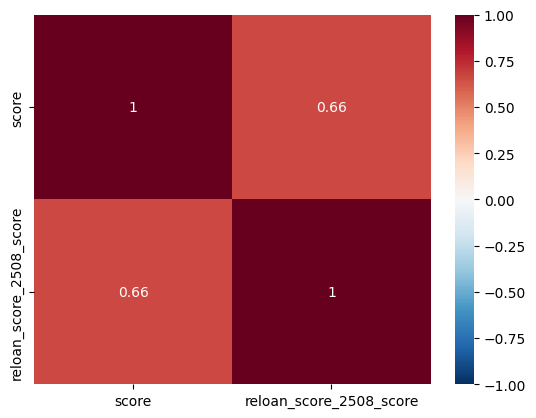

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_test_res[['score', 'reloan_score_2508_score']].corr(), annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.show()

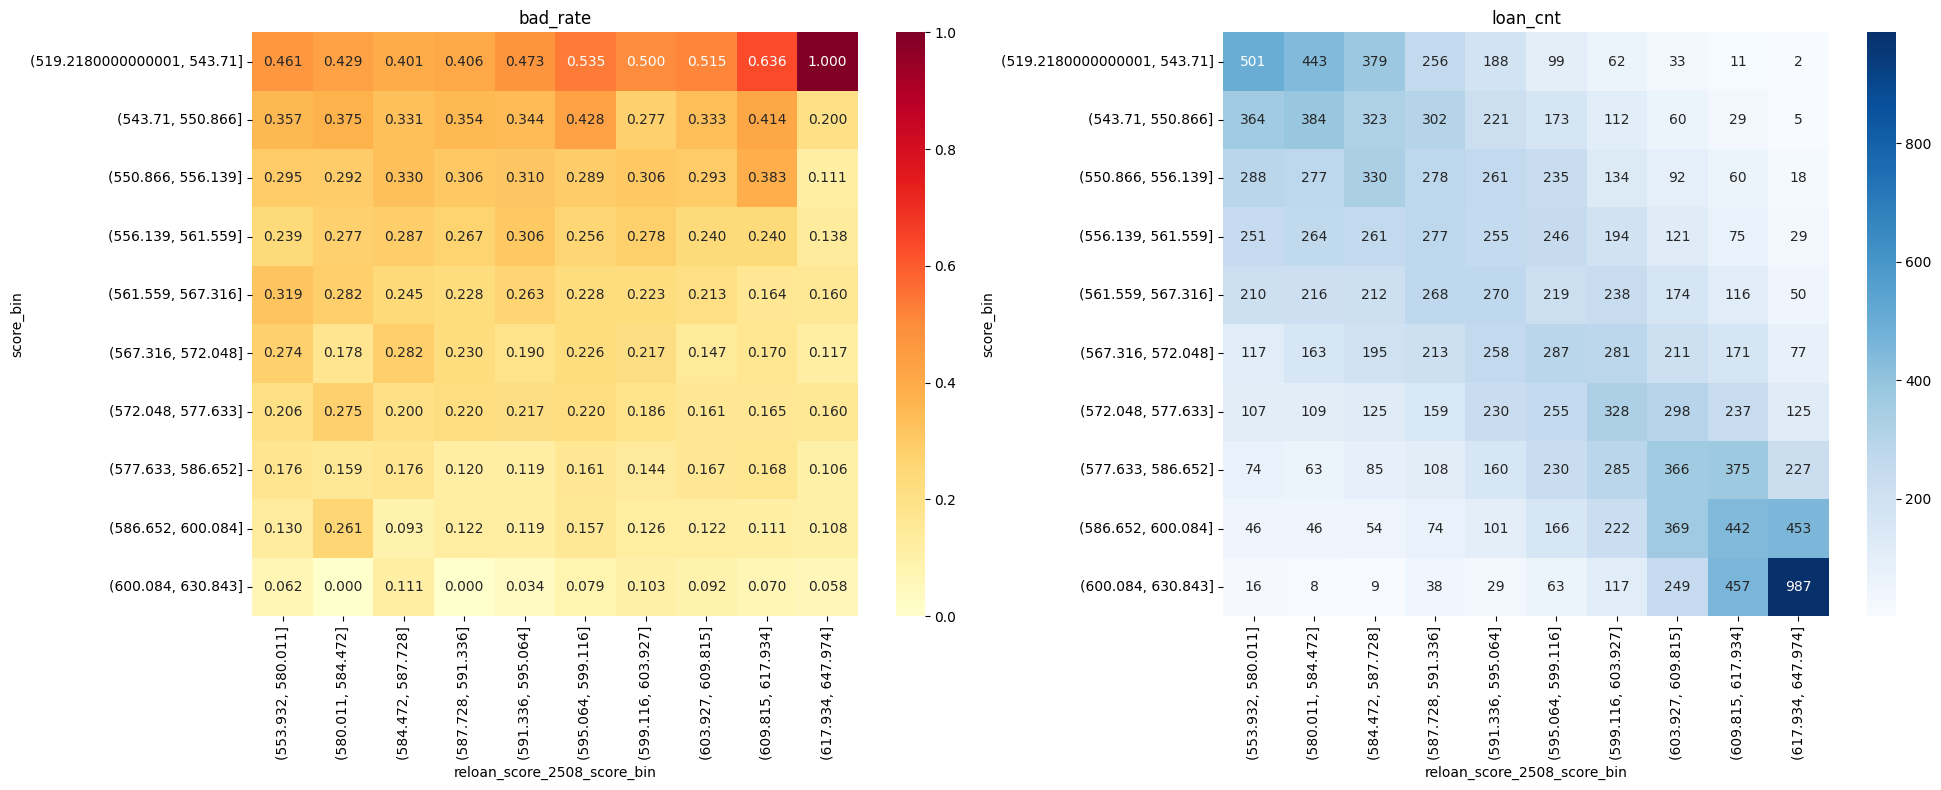

In [26]:
# 1. 分别等频十分箱
df_oot_res['score_bin'] = pd.qcut(df_oot_res['score'], q=10, duplicates='drop')
df_oot_res['reloan_score_2508_score_bin'] = pd.qcut(df_oot_res['reloan_score_2508_score'], q=10, duplicates='drop')

# 2. 交叉统计 target 浓度（坏样本率）
cross = df_oot_res.pivot_table(
    values='target',
    index='score_bin',
    columns='reloan_score_2508_score_bin',
    aggfunc='mean'
)

# 3. 交叉统计每个格子的样本量（辅助参考）
cross_count = df_oot_res.pivot_table(
    values='target',
    index='score_bin',
    columns='reloan_score_2508_score_bin',
    aggfunc='count'
)

# 4. 热力图可视化
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cross, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('bad_rate')
axes[0].set_xlabel('reloan_score_2508_score_bin')
axes[0].set_ylabel('score_bin')

sns.heatmap(cross_count, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('loan_cnt')
axes[1].set_xlabel('reloan_score_2508_score_bin')
axes[1].set_ylabel('score_bin')

plt.tight_layout()
plt.show()